In [7]:
# Data Visualization Libraries
from pathlib import Path
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "raw"
METADATA_PATH = DATA_DIR / "metadata.csv"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Metadata Path: {METADATA_PATH}")

Project Root: c:\Users\User\OneDrive\Desktop\Year-2-Recess-Project
Metadata Path: c:\Users\User\OneDrive\Desktop\Year-2-Recess-Project\data\raw\metadata.csv


In [9]:
# Load Dataset Metadata

if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file not found: {METADATA_PATH}")

metadata = pd.read_csv(METADATA_PATH)

print("Metadata loaded successfully")
print("--------------------------------")
print(f"Dataset shape: {metadata.shape}")

print("\nColumns:")
print(metadata.columns.tolist())

display(metadata.head())

Metadata loaded successfully
--------------------------------
Dataset shape: (112120, 5)

Columns:
['File Path', 'Image Index', 'Finding Labels', 'Label', 'Split']


,File Path,Image Index,Finding Labels,Label,Split
0,train/abnormal/00014520_017.png,00014520_017.png,Infiltration,abnormal,train
1,train/normal/00019496_000.png,00019496_000.png,No Finding,normal,train
2,train/abnormal/00014822_041.png,00014822_041.png,Effusion|Pleural_Thickening|Pneumothorax,abnormal,train
3,train/normal/00017510_000.png,00017510_000.png,No Finding,normal,train
4,train/abnormal/00005298_005.png,00005298_005.png,Infiltration|Pleural_Thickening,abnormal,train


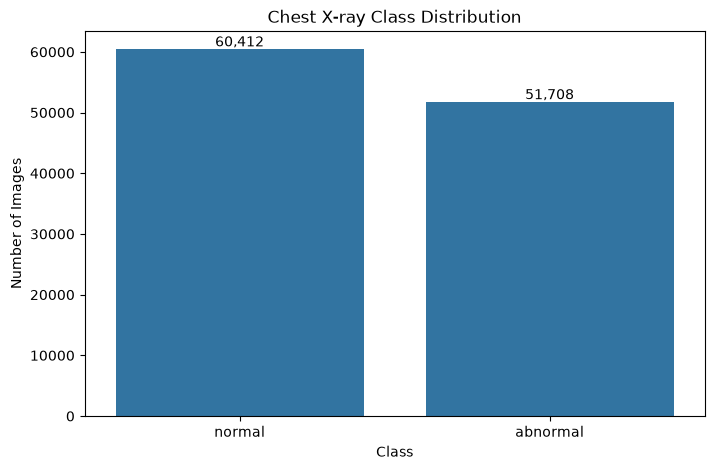

Class distribution:
Label
normal      60412
abnormal    51708
Name: count, dtype: int64


In [10]:
# Class Distribution Visualization

plt.figure(figsize=(8, 5))

class_counts = metadata["Label"].value_counts()

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Chest X-ray Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i, value in enumerate(class_counts.values):
    plt.text(
        i,
        value + 500,
        f"{value:,}",
        ha="center"
    )

plt.show()

print("Class distribution:")
print(class_counts)

Number of unique findings: 15


Finding Labels
No Finding            60412
Infiltration          19870
Effusion              13307
Atelectasis           11535
Nodule                 6323
Mass                   5746
Pneumothorax           5298
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2772
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1353
Hernia                  227
Name: count, dtype: int64

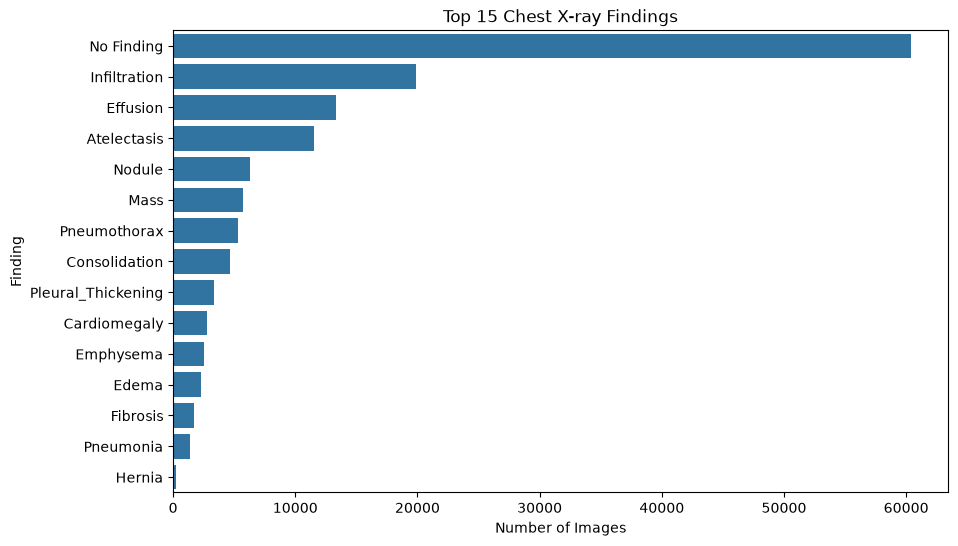

In [11]:
# Finding Labels Distribution

# Split multiple findings into separate rows
findings = (
    metadata["Finding Labels"]
    .str.split("|")
    .explode()
)

finding_counts = findings.value_counts()

print("Number of unique findings:", len(finding_counts))

display(finding_counts.head(15))


# Plot top 15 findings

plt.figure(figsize=(10, 6))

sns.barplot(
    y=finding_counts.head(15).index,
    x=finding_counts.head(15).values
)

plt.title("Top 15 Chest X-ray Findings")
plt.xlabel("Number of Images")
plt.ylabel("Finding")

plt.show()

Dataset Split Distribution
--------------------------
Split
train    89696
val      11212
test     11212
Name: count, dtype: int64


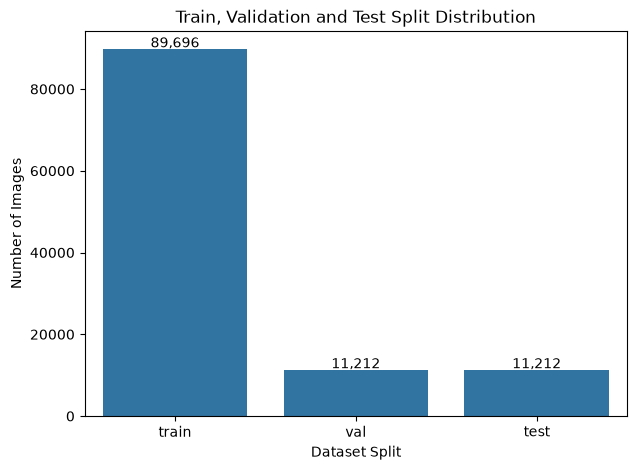

In [12]:
# Dataset Split Distribution

split_counts = metadata["Split"].value_counts()

print("Dataset Split Distribution")
print("--------------------------")
print(split_counts)


plt.figure(figsize=(7, 5))

sns.barplot(
    x=split_counts.index,
    y=split_counts.values
)

plt.title("Train, Validation and Test Split Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

for i, value in enumerate(split_counts.values):
    plt.text(
        i,
        value + 500,
        f"{value:,}",
        ha="center"
    )

plt.show()

In [13]:
# Prepare Features for PCA/t-SNE Visualization

from sklearn.preprocessing import LabelEncoder

# Encode labels
encoder = LabelEncoder()

metadata["Label_encoded"] = encoder.fit_transform(metadata["Label"])

print("Label encoding:")
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Select categorical features from findings
finding_features = (
    metadata["Finding Labels"]
    .str.get_dummies(sep="|")
)

# Combine features
feature_data = pd.concat(
    [
        finding_features,
        metadata[["Label_encoded"]]
    ],
    axis=1
)

print("\nFeature matrix shape:")
print(feature_data.shape)

display(feature_data.head())

Label encoding:
{'abnormal': np.int64(0), 'normal': np.int64(1)}

Feature matrix shape:
(112120, 16)


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Label_encoded
0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0


In [14]:
# PCA Feature Space Visualization

# Separate features and labels
X = feature_data.drop("Label_encoded", axis=1)
y = feature_data["Label_encoded"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Label"] = metadata["Label"].values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

display(pca_df.head())

Explained variance ratio:
[0.1469146  0.08297905]


,PC1,PC2,Label
0,-0.921709,0.573195,abnormal
1,1.272075,0.043464,normal
2,-2.878782,-3.047144,abnormal
3,1.272075,0.043464,normal
4,-1.907076,-0.526844,abnormal


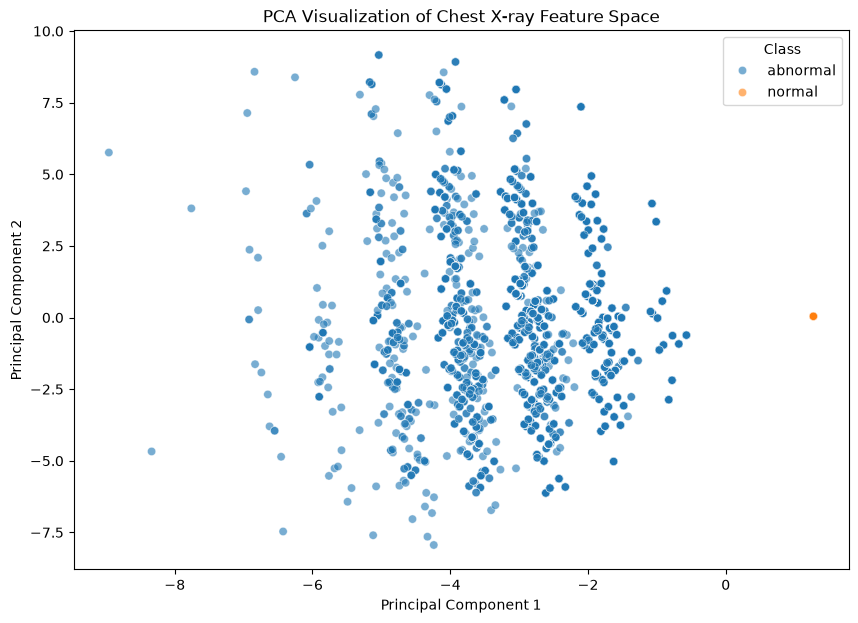

In [15]:
# PCA Feature Space Visualization

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Label",
    alpha=0.6
)

plt.title("PCA Visualization of Chest X-ray Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Class")
plt.show()

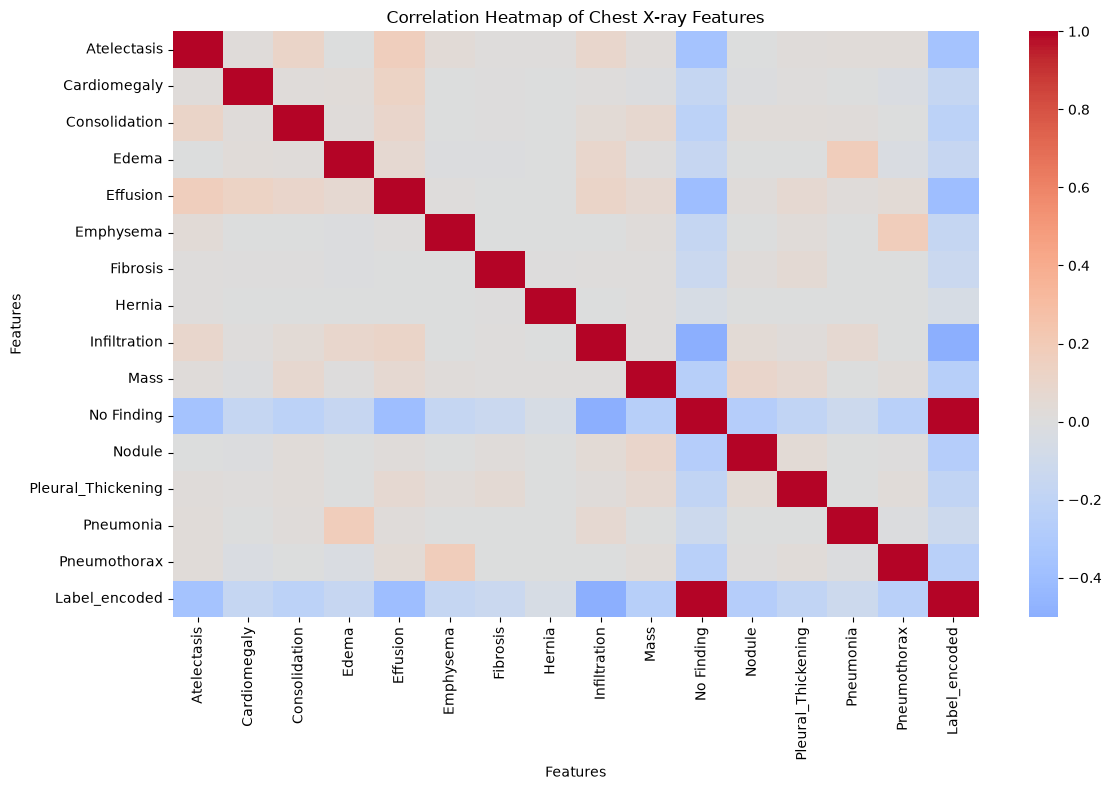

In [18]:
# Feature Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = feature_data.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Chest X-ray Features")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [20]:
# 3D Scatter Plot of Top 3 Features

# Calculate feature variance
feature_variance = X.var().sort_values(ascending=False)

top_features = feature_variance.head(3).index.tolist()

print("Top 3 features selected:")
print(top_features)


plot_3d_data = feature_data[top_features].copy()

plot_3d_data["Label"] = metadata["Label"]


fig = px.scatter_3d(
    plot_3d_data,
    x=top_features[0],
    y=top_features[1],
    z=top_features[2],
    color="Label",
    title=f"3D Feature Interaction: {top_features}",
    opacity=0.6
)

fig.show()

Top 3 features selected:
['No Finding', 'Infiltration', 'Effusion']


## Visualization Summary

This notebook performs exploratory data analysis and feature visualization of the chest X-ray dataset.

Completed analyses:
- Class distribution analysis
- Disease finding frequency analysis
- Dataset split visualization
- PCA feature space visualization
- Feature correlation analysis
- 3D feature interaction visualization

Model-specific visualizations such as feature importance and model comparison charts will be generated after model training.